In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주현 데이터, 순위 x)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위 O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터 불러오기

In [2]:
train_df = pd.read_csv('data/titanic_train5.csv')
test_df = pd.read_csv('data/titanic_test5.csv')

### 분산 선택
- 분산 변화가 거의 없는 컬럼들을 제거한다

In [3]:
# 분산이 0.1보다 작은 데이터들을 찾는다
selector = VarianceThreshold(threshold = 0.01)
selector.fit(train_df)

VarianceThreshold(threshold=0.01)

In [4]:
# 결과를 확인한다
selected_df = train_df.iloc[:, selector.get_support()]
print(f'변환 후 피처 개수 : {selected_df.shape[1]}')
print(f'제거된 피처 개수 : {set(train_df.columns) - set(selected_df.columns)}')

변환 후 피처 개수 : 18
제거된 피처 개수 : set()


### 다중 공선성이 있는 컬럼 제거

In [5]:
# 결과데이터를 제외한 나머지들을 가져온다.
temp_df = train_df.drop('Survived', axis =1)
corr_matrix = temp_df.corr()
corr_matrix

,Unnamed: 0,Sex,Parch,Fare,isChild,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Embarked_S,Title_Master,Title_Miss,Title_Mr,Title_Mrs,FamilySizeGroup_0,FamilySizeGroup_1,FamilySizeGroup_2
Unnamed: 0,1.000000,0.042939,-0.001652,-0.007425,-0.009668,0.034303,-0.000086,-0.029486,-0.001205,0.022204,-0.026151,-0.067731,0.038850,0.010256,0.057462,-0.028976,-0.057055
Sex,0.042939,1.000000,-0.245489,-0.263276,-0.077893,-0.098013,-0.064746,0.137143,-0.082853,0.119224,0.159934,-0.693916,0.867334,-0.550146,0.303646,-0.260747,-0.102954
Parch,-0.001652,-0.245489,1.000000,0.332186,0.364779,-0.017633,-0.000734,0.015790,-0.011069,0.060814,0.267344,0.100998,-0.333905,0.223575,-0.583398,0.265863,0.631523
Fare,-0.007425,-0.263276,0.332186,1.000000,0.097960,0.663226,-0.039771,-0.539071,0.262341,-0.128846,0.093820,0.115668,-0.306288,0.217721,-0.478410,0.378834,0.221216
isChild,-0.009668,-0.077893,0.364779,0.097960,1.000000,-0.127772,0.034173,0.082277,-0.014698,0.032701,0.656730,0.196774,-0.337567,-0.119420,-0.337008,0.165392,0.343017
Pclass_1,0.034303,-0.098013,-0.017633,0.663226,-0.127772,1.000000,-0.288585,-0.626738,0.296423,-0.161921,-0.084700,0.020348,-0.097288,0.093608,-0.113364,0.168568,-0.092945
Pclass_2,-0.000086,-0.064746,-0.000734,-0.039771,0.034173,-0.288585,1.000000,-0.565210,-0.125416,0.189980,0.009903,-0.021903,-0.088569,0.119193,-0.039070,0.104546,-0.117721
Pclass_3,-0.029486,0.137143,0.015790,-0.539071,0.082277,-0.626738,-0.565210,1.000000,-0.153329,-0.015104,0.064918,0.000293,0.155907,-0.177658,0.129472,-0.230325,0.175890
Embarked_C,-0.001205,-0.082853,-0.011069,0.262341,-0.014698,0.296423,-0.125416,-0.153329,1.000000,-0.782742,-0.035225,0.036204,-0.072567,0.067872,-0.095298,0.158586,-0.109274
Embarked_S,0.022204,0.119224,0.060814,-0.128846,0.032701,-0.161921,0.189980,-0.015104,-0.782742,1.000000,0.024264,-0.137144,0.112870,-0.002550,0.029074,-0.084120,0.099265


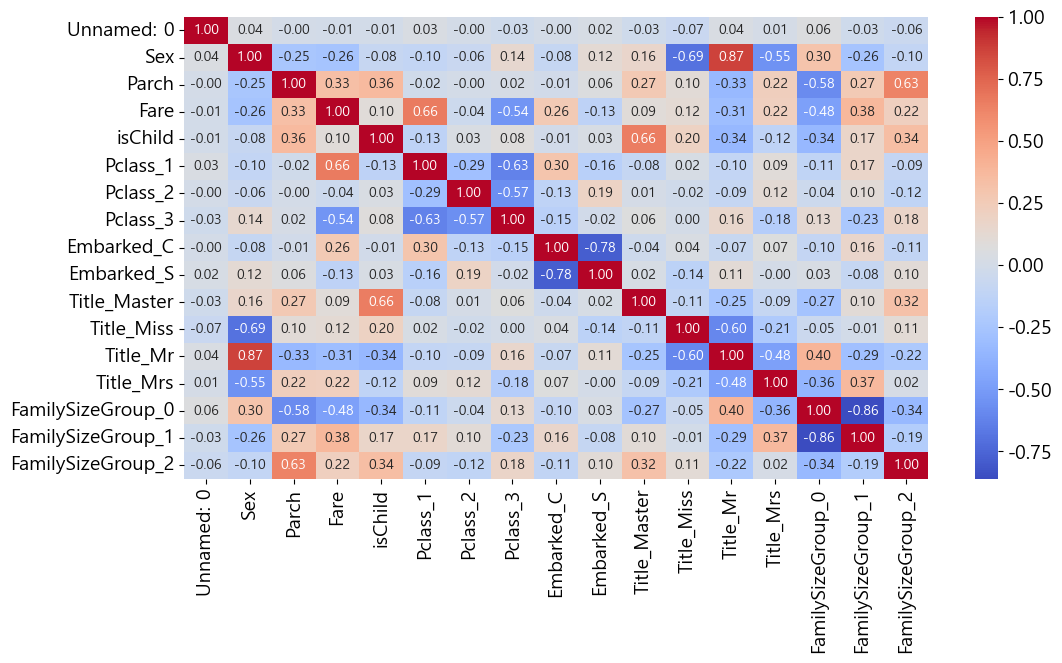

In [6]:
# 히트맵
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar=True, annot_kws={'size':10})
plt.show()

In [7]:
# 상관계수 0.7 이상인 쌍을 찾아낸다.
for i in range(len(corr_matrix.columns)) : 
    for j in range(i) :
        if abs(corr_matrix.iloc[i,j]) > 0.7 :
            col_name = corr_matrix.columns[i]
            row_name = corr_matrix.columns[j]
            print(f'{row_name} - {col_name} : {corr_matrix.iloc[i,j]:.2f}')

Embarked_C - Embarked_S : -0.78
Sex - Title_Mr : 0.87
FamilySizeGroup_0 - FamilySizeGroup_1 : -0.86


In [8]:
# 컬럼을 제거한다.
a1 = ['Embarked_S', 'Title_Mr', 'FamilySizeGroup_1']
train_df.drop(a1, axis=1, inplace=True)
test_df.drop(a1, axis=1, inplace=True)

display(train_df)
display(test_df)

,Unnamed: 0,Survived,Sex,Parch,Fare,isChild,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Title_Master,Title_Miss,Title_Mrs,FamilySizeGroup_0,FamilySizeGroup_2
0,0,0,1,0,2.110213,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1,1,0,0,4.280593,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,2,1,0,0,2.188856,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,1,0,0,3.990834,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,4,0,1,0,2.202765,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,886,0,1,0,2.639057,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
887,887,1,0,0,3.433987,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
888,888,0,0,2,3.196630,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
889,889,1,1,0,3.433987,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


,Unnamed: 0,Sex,Parch,Fare,isChild,Pclass_1,Pclass_2,Pclass_3,Embarked_C,Title_Master,Title_Miss,Title_Mrs,FamilySizeGroup_0,FamilySizeGroup_2
0,0,1,0,2.178064,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1,0,0,2.079442,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2,1,0,2.369075,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,3,1,0,2.268252,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,0,1,2.586824,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,413,1,0,2.202765,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
414,414,0,0,4.699571,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
415,415,1,0,2.110213,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
416,416,1,0,2.202765,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [9]:
train_df.to_csv('data/titanic_train6.csv', index=False)
test_df.to_csv('data/titanic_test6.csv',index=False)